#**Projeto Interdisciplinar: Ciência de Dados**

## Entrega 1

## **Etapa 1 - Fonte de Dados**

A principal fonte de dados utilizada neste projeto foi fornecida pela **CTI Global**, empresa parceira do Projeto Interdisciplinar.

- **Arquivo:** `Demonstrativo Fecap v3.csv`
- **Tipo de fonte:** Fonte institucional fornecida pela empresa parceira.
- **Formato:** CSV.
- **Conteúdo:** Dados financeiros utilizados para análise de planejamento e desempenho financeiro, contendo informações relacionadas a demonstrações contábeis e diferentes cenários e períodos.
- **Finalidade:** Os dados serão utilizados nas etapas de preparação, tratamento, análise estatística, cálculo de indicadores financeiros e desenvolvimento de um dashboard para apoio à tomada de decisões estratégicas e operacionais.

## **Etapa 2 - Coletar dados iniciais**

In [29]:
import pandas as pd
import numpy as np

caminho_arquivo = "Demonstrativo Fecap v3.csv"

colunas = ["ano", "cenario", "conta", "valor"]

df = pd.read_csv(
    caminho_arquivo,
    sep=";",
    encoding="latin-1",
    header=None,
    names=colunas,
    dtype=str,
)

print("Formato bruto:", df.shape)
df.head(10)

Formato bruto: (1002000, 4)


,ano,cenario,conta,valor
0,Ano 1,Total Cen_00001,NaN,"0,025138815"
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,"10.631.127.075,2579"
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,"1.795.720.872,17537"
3,Ano 1,Total Cen_00001,BAL - Disponível,"1.205.264.965,51818"
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,"95.680.421,9232409"
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,"584.661,46688296"
6,Ano 1,Total Cen_00001,BAL - Contas a Receber - Clientes,"453.870.957,151068"
7,Ano 1,Total Cen_00001,BAL - Estoques Diversos,"86.620,78872148"
8,Ano 1,Total Cen_00001,BAL - Outros Créditos,"40.233.245,3272782"
9,Ano 1,Total Cen_00001,BAL - Realizável a Longo Prazo,"639.023.858,22772"


## **Etapa 3 - Descrevendo os dados**

**OBS:** Esta estapa está disponível como arquivo .pdf, você pode encontrá-lo em: [Descrição dos Dados.pdf](https://github.com/2026-2-NCC4/Projeto7/blob/main/Documentos/Entrega%201/Projeto%20Interdisciplinar%20Ci%C3%AAncia%20de%20Dados/DescricaoDadosPI.pdf)

## **Etapa 4 - Explorando os dados**

In [30]:
# linhas iniciais
df.head()

,ano,cenario,conta,valor
0,Ano 1,Total Cen_00001,NaN,"0,025138815"
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,"10.631.127.075,2579"
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,"1.795.720.872,17537"
3,Ano 1,Total Cen_00001,BAL - Disponível,"1.205.264.965,51818"
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,"95.680.421,9232409"


In [31]:
# informações da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002000 entries, 0 to 1001999
Data columns (total 4 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   ano      1002000 non-null  object
 1   cenario  1002000 non-null  object
 2   conta    958800 non-null   object
 3   valor    1002000 non-null  object
dtypes: object(4)
memory usage: 30.6+ MB


In [32]:
# quantidade de valores faltantes
df.isnull().sum()

,0
ano,0
cenario,0
conta,43200
valor,0


In [33]:
# quantidade de registros duplicados
df.duplicated().sum()

np.int64(14400)

In [34]:
# quantidade de anos diferentes
df["ano"].nunique()

12

In [35]:
# valores existentes na coluna ano
df["ano"].unique()

array(['Ano 1', 'Ano 2', 'Ano 3', 'Ano 4', 'Ano 5', 'Ano 6', 'Ano 7',
       'Ano 8', 'Ano 9', 'Ano 10', 'Ano 11', 'Ano 12'], dtype=object)

In [36]:
df["cenario"].nunique()

1200

In [37]:
df["cenario"].unique()

array(['Total Cen_00001', 'Total Cen_00002', 'Total Cen_00003', ...,
       'Total Cen_01198', 'Total Cen_01199', 'Total Cen_01200'],
      dtype=object)

In [38]:
df["conta"].nunique()

69

In [39]:
df["conta"].unique()

array([nan, 'BAL - Total do Ativo', 'BAL - Ativo Circulante',
       'BAL - Disponível', 'BAL - Contas a Receber - SWAP',
       'BAL - Contas a Receber - Partes Relacionadas',
       'BAL - Contas a Receber - Clientes', 'BAL - Estoques Diversos',
       'BAL - Outros Créditos', 'BAL - Realizável a Longo Prazo',
       'BAL - At Fiscal Diferido', 'BAL - Créditos Tributários',
       'BAL - Outorga da Concessão', 'BAL - Outros Créditos LP',
       'BAL - Permanente', 'BAL - Investimentos - Imobilizado',
       'BAL - Investimentos - Intangível', 'BAL - Diferido',
       'BAL - Depreciação Acumulada', 'BAL - Amortização Acumulada',
       'BAL - Amortização - Intangível', 'BAL - Total do Passivo',
       'BAL - Passivo Circulante', 'BAL - Empréstimos',
       'BAL - Contas a Pagar - Parte Relacionada', 'BAL - Fornecedores',
       'BAL - Encargos Sociais e Trabalhistas', 'BAL - Tributos a pagar',
       'BAL - Impostos', 'BAL - Obrigações com o Poder Concedente',
       'BAL - Outros Déb

In [40]:
# verificando quais contas aparecem mais
df["conta"].value_counts().head(15)

,count
conta,
BAL - Total do Ativo,14400
BAL - Ativo Circulante,14400
BAL - Disponível,14400
BAL - Outros Créditos,14400
BAL - Contas a Receber - Clientes,14400
FLU - Saldo Final,14400
FLU - Geração de Caixa,14400
BAL - Realizável a Longo Prazo,14400
BAL - At Fiscal Diferido,14400


In [41]:
# verificando quais cenarios aparecem mais
df["cenario"].value_counts().head(15)

,count
cenario,
Total Cen_01184,835
Total Cen_01183,835
Total Cen_01182,835
Total Cen_01181,835
Total Cen_01180,835
Total Cen_01179,835
Total Cen_01178,835
Total Cen_01177,835
Total Cen_01176,835


In [42]:
df["valor"].head(20)

,valor
0,"0,025138815"
1,"10.631.127.075,2579"
2,"1.795.720.872,17537"
3,"1.205.264.965,51818"
4,"95.680.421,9232409"
5,"584.661,46688296"
6,"453.870.957,151068"
7,"86.620,78872148"
8,"40.233.245,3272782"
9,"639.023.858,22772"


### **Gráfico 1:** Quantidade de registros por ano

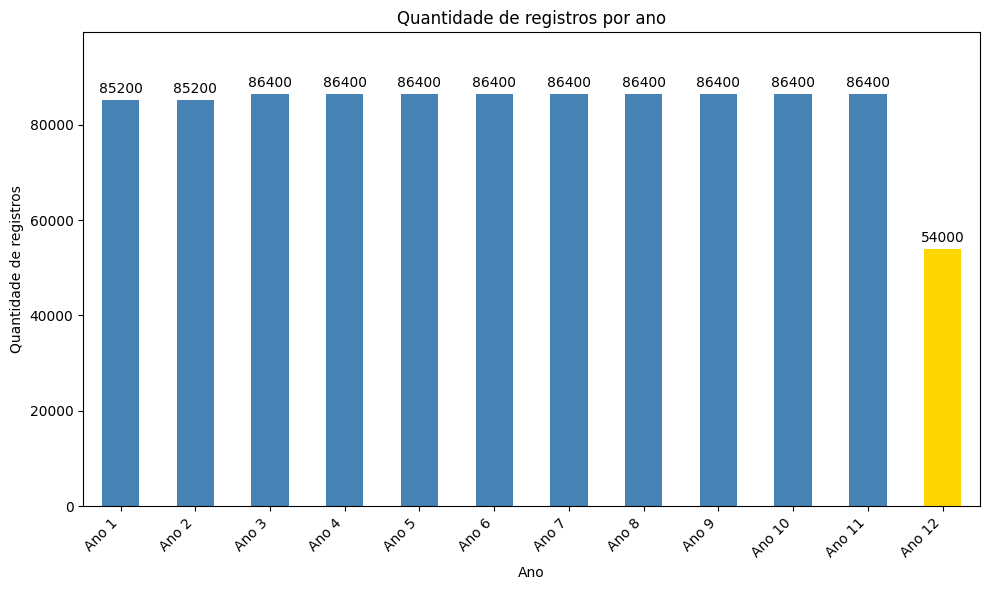

In [43]:
# quantidade de registros por ano
import matplotlib.pyplot as plt

contagem = df["ano"].value_counts()

# ordena os anos em ordem crescente
contagem = contagem.reindex(
    sorted(contagem.index, key=lambda x: int(x.split()[-1]))
)

cores = ["gold" if valor < 60000 else "steelblue" for valor in contagem]

fig, ax = plt.subplots(figsize=(10, 6))
contagem.plot(kind="bar", color=cores, ax=ax)

# formata o número para milhar
ax.bar_label(ax.containers[0], fmt="{:.0f}".format, padding=3)

# gera uma margem entre uma barra e a outra para não cortar os números
ax.set_ylim(0, contagem.max() * 1.15)

plt.title("Quantidade de registros por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Gráfico 2:** Contas com maior quantidade de registros

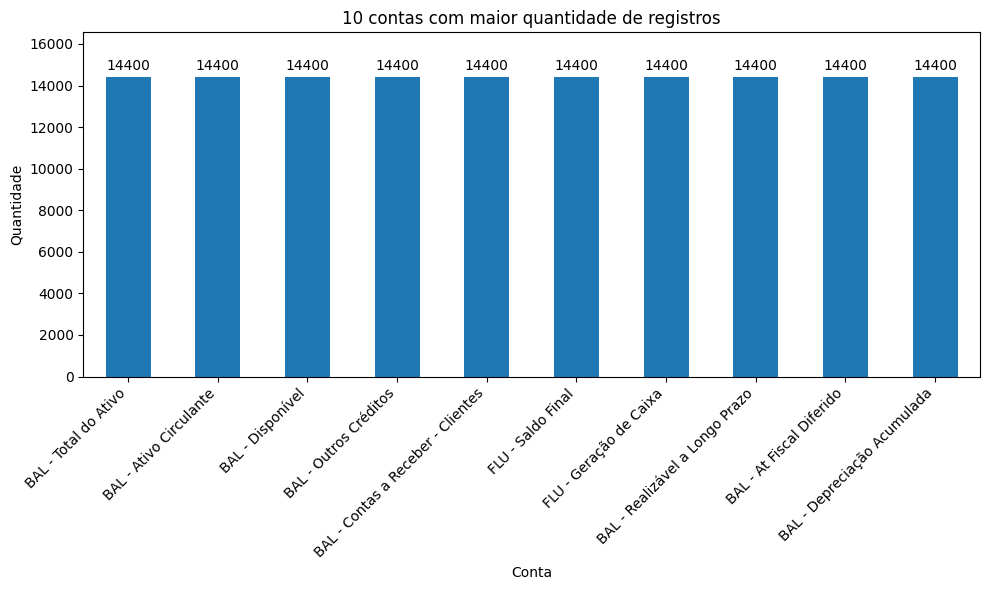

In [44]:
# contas com maior quantidade de registros
contagem = df["conta"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))

contagem.plot(kind="bar", ax=ax)

# formata o número para milhar
ax.bar_label(ax.containers[0], fmt="{:.0f}".format, padding=3)

# gera uma margem entre uma barra e a outra para não cortar os números
ax.set_ylim(0, contagem.max() * 1.15)

plt.title("10 contas com maior quantidade de registros")
plt.xlabel("Conta")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Gráfico 3:** Contas com menor quantidade de registros

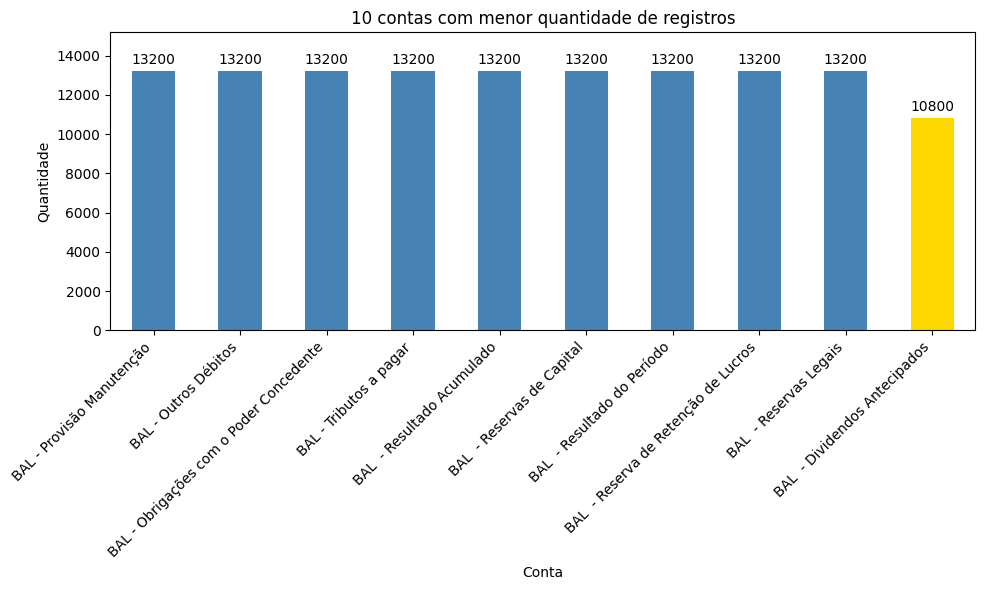

In [45]:
# contas com menor quantidade de registros
contagem = df["conta"].value_counts().tail(10)

fig, ax = plt.subplots(figsize=(10, 6))

cores = ["gold" if valor < 11000 else "steelblue" for valor in contagem]

contagem.plot(kind="bar", color=cores,ax=ax)

# formata o número para milhar
ax.bar_label(ax.containers[0], fmt="{:.0f}".format, padding=3)

# gera uma margem entre uma barra e a outra para não cortar os números
ax.set_ylim(0, contagem.max() * 1.15)

plt.title("10 contas com menor quantidade de registros")
plt.xlabel("Conta")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Gráfico 4:** Distribuição de contas por categoria

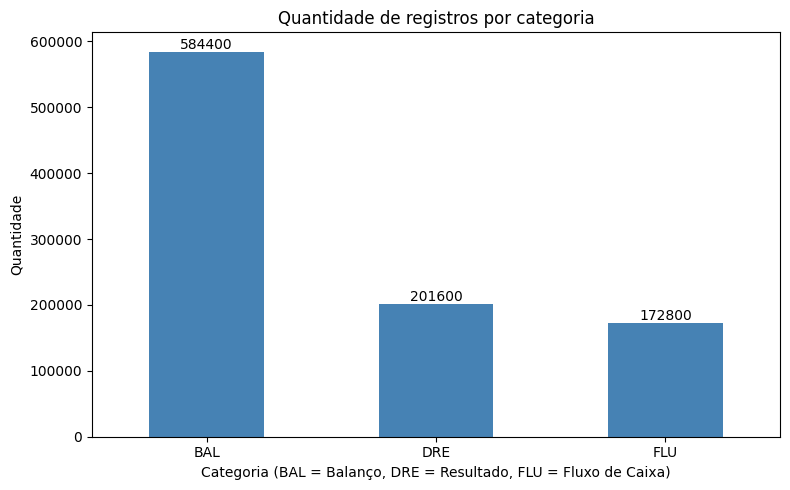

In [46]:
# distribuicao de contas por categoria
df["categoria"] = df["conta"].str.split(" - ").str[0].str.strip()

contagem = df["categoria"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

contagem.plot(kind="bar", color="steelblue", ax=ax)

ax.bar_label(ax.containers[0])

plt.title("Quantidade de registros por categoria")
plt.xlabel("Categoria (BAL = Balanço, DRE = Resultado, FLU = Fluxo de Caixa)")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Gráfico 5:** Proporção de registros por categoria

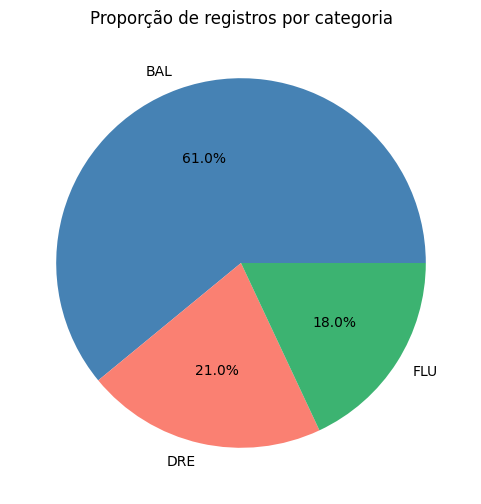

In [47]:
# proporcao de registros por categoria
contagem_categoria = df["categoria"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    contagem_categoria,
    labels=contagem_categoria.index,
    autopct="%1.1f%%",
    colors=["steelblue", "salmon", "mediumseagreen"]
)
plt.title("Proporção de registros por categoria")
plt.show()

### **Gráfico 6:** Soma total de valor por ano

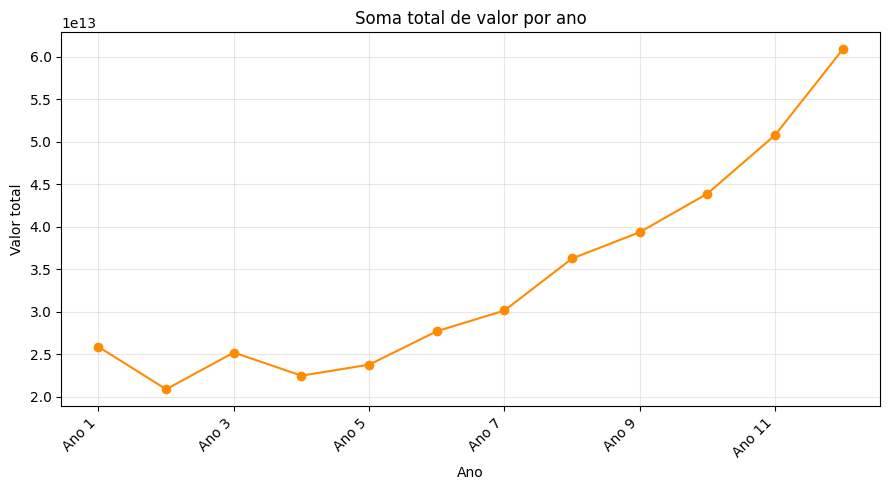

In [48]:
# soma total de valor por ano
# convertendo a coluna valor para numero
df["valor_num"] = (
    df["valor"]
    .str.replace(".", "", regex=False)   # remove o separador de milhar
    .str.replace(",", ".", regex=False)  # troca a virgula por ponto decimal
    .astype(float)
)

soma_ano = df.groupby("ano")["valor_num"].sum()

# ordendando os anos
soma_ano = soma_ano.reindex(sorted(soma_ano.index, key=lambda x: int(x.split()[-1])))

plt.figure(figsize=(9, 5))
soma_ano.plot(kind="line", marker="o", color="darkorange")
plt.title("Soma total de valor por ano")
plt.xlabel("Ano")
plt.ylabel("Valor total")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
# recarregando os dados originais antes de iniciar o tratamento
df = pd.read_csv(
    caminho_arquivo,
    sep=";",
    encoding="latin-1",
    header=None,
    names=["ano", "cenario", "conta", "valor"],
    dtype=str,
)

**OBS:** Para encontrar a interpretação da exploração dos dados e os gráficos gerados nesta etapa, você pode encontrar o arquivo .pdf em: [Exploração dos Dados.pdf](https://github.com/2026-2-NCC4/Projeto7/blob/main/Documentos/Entrega%201/Projeto%20Interdisciplinar%20Ci%C3%AAncia%20de%20Dados/Exploracao_Dados.pdf)

## **Etapa 5 - Selecionando os Dados**

Nesta etapa, realizamos a seleção dos dados da base, removendo registros que não trazem informação útil para a análise.
Durante a etapa de exploração inicial, identificamos que a coluna `conta` possuía 43.200 valores nulos, ou seja, registros sem nenhuma informação sobre a qual conta o valor pertencia.

Como esses registros vazios não agregam em nada a nossa análise, os removemos da base, mantendo apenas as linhas em que a coluna `conta` possui registros.

In [50]:
# removendo registros sem informação útil
# (linhas onde 'conta' é nula não trazem informacoes úteis)
df_selecionado = df[df["conta"].notna()].copy()

print(f"Registros antes da seleção: {len(df)}")
print(f"Registros depois da seleção: {len(df_selecionado)}")
print(f"Registros removidos no processo: {len(df) - len(df_selecionado)}")

Registros antes da seleção: 1002000
Registros depois da seleção: 958800
Registros removidos no processo: 43200


## **Etapa 6 - Limpando e uniformizando os dados**

In [51]:
# uniformizando espaços nas colunas de texto
df_selecionado["conta"] = df_selecionado["conta"].str.replace(r"\s+", " ", regex=True).str.strip()
df_selecionado["cenario"] = df_selecionado["cenario"].str.strip()
df_selecionado["ano"] = df_selecionado["ano"].str.strip()

# convertendo 'valor' de texto para número
df_selecionado["valor"] = (
    df_selecionado["valor"]
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_selecionado.head()

,ano,cenario,conta,valor
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09
3,Ano 1,Total Cen_00001,BAL - Disponível,1.205265e+09
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,5.846615e+05


## **Etapa 7 - Derivando e integrando os dados**

In [52]:
# derivando a coluna 'categoria' de acordo com cada conta (BAL, DRE ou FLU)
df_selecionado["categoria"] = df_selecionado["conta"].str.split(" - ").str[0].str.strip()

# derivando 'ano_num' extraindo o número do texto "Ano X" (fizemos isso para melhor ordenacao)
df_selecionado["ano_num"] = df_selecionado["ano"].str.extract(r"(\d+)").astype(int)

print("Categorias derivadas:", df_selecionado["categoria"].unique())
df_selecionado.head()

Categorias derivadas: ['BAL' 'DRE' 'FLU']


,ano,cenario,conta,valor,categoria,ano_num
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10,BAL,1
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09,BAL,1
3,Ano 1,Total Cen_00001,BAL - Disponível,1.205265e+09,BAL,1
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07,BAL,1
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,5.846615e+05,BAL,1


## **Etapa 8 - Formatando os dados**

In [53]:
# reorganizando a ordem das colunas
df_final = df_selecionado[["ano", "ano_num", "cenario", "conta", "categoria", "valor"]]

# aqui resetamos o indice apos algumas remocoes feitas em etapas anteriores
df_final = df_final.reset_index(drop=True)

# verificando os tipos de cada coluna
print(df_final.dtypes)
df_final.head()

ano           object
ano_num        int64
cenario       object
conta         object
categoria     object
valor        float64
dtype: object


,ano,ano_num,cenario,conta,categoria,valor
0,Ano 1,1,Total Cen_00001,BAL - Total do Ativo,BAL,1.063113e+10
1,Ano 1,1,Total Cen_00001,BAL - Ativo Circulante,BAL,1.795721e+09
2,Ano 1,1,Total Cen_00001,BAL - Disponível,BAL,1.205265e+09
3,Ano 1,1,Total Cen_00001,BAL - Contas a Receber - SWAP,BAL,9.568042e+07
4,Ano 1,1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,BAL,5.846615e+05


In [54]:
# salvando a base tratada e formatada
df_final.to_csv("Demonstrativo_Fecap_tratado.csv", index=False)
print("base salva")

base salva
